<h3>ANOVA de una via</h3>

In [1]:
load('.RData')
options(warn = 0)

In [25]:
library(rapportools)
library(car)

Loading required package: carData



In [3]:
## Eliminamos los valores NA
df <- na.omit(df_penguins)
head(df)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


<h4>Valores atípicos</h4>

In [4]:
for (variable in colnames(df[, 3:6]))

for (penguin in unique(df$species)){
    print(variable)
    print(paste(penguin, rp.outlier(as.numeric(unlist(df[df$species == penguin, variable])))), sep = ' - ')
}

[1] "bill_length_mm"
[1] "Adelie "
[1] "bill_length_mm"
[1] "Gentoo 59.6"
[1] "bill_length_mm"
[1] "Chinstrap "
[1] "bill_depth_mm"
[1] "Adelie "
[1] "bill_depth_mm"
[1] "Gentoo "
[1] "bill_depth_mm"
[1] "Chinstrap "
[1] "flipper_length_mm"
[1] "Adelie "
[1] "flipper_length_mm"
[1] "Gentoo "
[1] "flipper_length_mm"
[1] "Chinstrap "
[1] "body_mass_g"
[1] "Adelie "
[1] "body_mass_g"
[1] "Gentoo "
[1] "body_mass_g"
[1] "Chinstrap "


<h4>Prueba de normalidad de Shapiro-Wilks</h4>
Para esta prueba la hipótesis nula implica que los datos siguen una distribución normal. Por tanto, si el p-valor de la prueba es inferior a 0.05, se rechaza la hipótesis nula y diremos que la respuesta no sigue una distribución normal. Si el p-value > 0.05 no estaremos incumpliento el supuesto de normalidad

In [24]:
#by(df$bill_length_mm, interaction(df$species, df$sex), shapiro.test) 
# Gentoo.male=0.005105; Chinstrap.female=0.001695

#by(df$bill_depth_mm, interaction(df$species, df$sex), shapiro.test)   
# Adelie.male = 0.03352

#by(df$flipper_length_mm, interaction(df$species, df$sex), shapiro.test) 

#by(df$body_mass_g, interaction(df$species, df$sex), shapiro.test) 


<h4>Homogeneidad de varianza</h4>
La hipótesis nula implica que los datos presentan homogeneidad de varianza, por lo cual si el p-valor es inferior a 0.05 estaríamos incumpliendo la hipótesis nula. Si el p-valor es mayor a 0.05 existe homogeneidad de varianza.

In [32]:
#bartlett.test(df$bill_length_mm, interaction(df$species, df$sex))
# leveneTest(df$bill_length_mm, interaction(df$species, df$sex))
# fligner.test(df$bill_length_mm, interaction(df$species, df$sex))
# leveneTest(df$body_mass_g, interaction(df$species, df$sex))
# fligner.test(df$body_mass_g, interaction(df$species, df$sex))
# leveneTest(df$bill_depth_mm, interaction(df$species, df$sex))   <0.05
# fligner.test(df$bill_depth_mm, interaction(df$species, df$sex)) <0.05
# leveneTest(df$flipper_length_mm, interaction(df$species, df$sex))   <0.05
# fligner.test(df$flipper_length_mm, interaction(df$species, df$sex)) <0.05

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,5,2.407723,0.03652301
,327,NA,NA



	Fligner-Killeen test of homogeneity of variances

data:  df$flipper_length_mm and interaction(df$species, df$sex)
Fligner-Killeen:med chi-squared = 11.561, df = 5, p-value = 0.04133


<h4>ANOVA de una via</h4>
Hipotesis nula: no hay diferencias entre grupos.<br>
Hípotesis: si hay diferencias en alguno de los grupos.<br>
<b>Nota:</b> Aunque se incumplen algunos de los requisitos (normalidad y homocedasticidad), realizamos la prueba.

In [37]:
anova_body <- aov(body_mass_g ~ interaction(species, sex), data = df)
summary(anova_body)

                           Df   Sum Sq  Mean Sq F value Pr(>F)    
interaction(species, sex)   5 1.84e+08 36791408   384.3 <2e-16 ***
Residuals                 327 3.13e+07    95727                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [39]:
anova_flipper <- aov(flipper_length_mm ~ interaction(species, sex), data = df)
summary(anova_flipper)

                           Df Sum Sq Mean Sq F value Pr(>F)    
interaction(species, sex)   5  54761   10952   342.4 <2e-16 ***
Residuals                 327  10458      32                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [40]:
anova_bill_l <- aov(bill_length_mm ~ interaction(species, sex), data = df)
summary(anova_bill_l)

                           Df Sum Sq Mean Sq F value Pr(>F)    
interaction(species, sex)   5   8176  1635.1     305 <2e-16 ***
Residuals                 327   1753     5.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [42]:
anova_bill_d <- aov(bill_depth_mm ~ interaction(species, sex), data = df)
summary(anova_bill_d)

                           Df Sum Sq Mean Sq F value Pr(>F)    
interaction(species, sex)   5 1059.8   212.0   304.5 <2e-16 ***
Residuals                 327  227.6     0.7                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

<p>Existen diferencias significativas entre los grupos</p>
<h4>Pruebas Post Hoc</h4>
Para encontrar los grupos significativamente distintos se realiza mediante la prueba de comparación multiple post hoc de Tukey

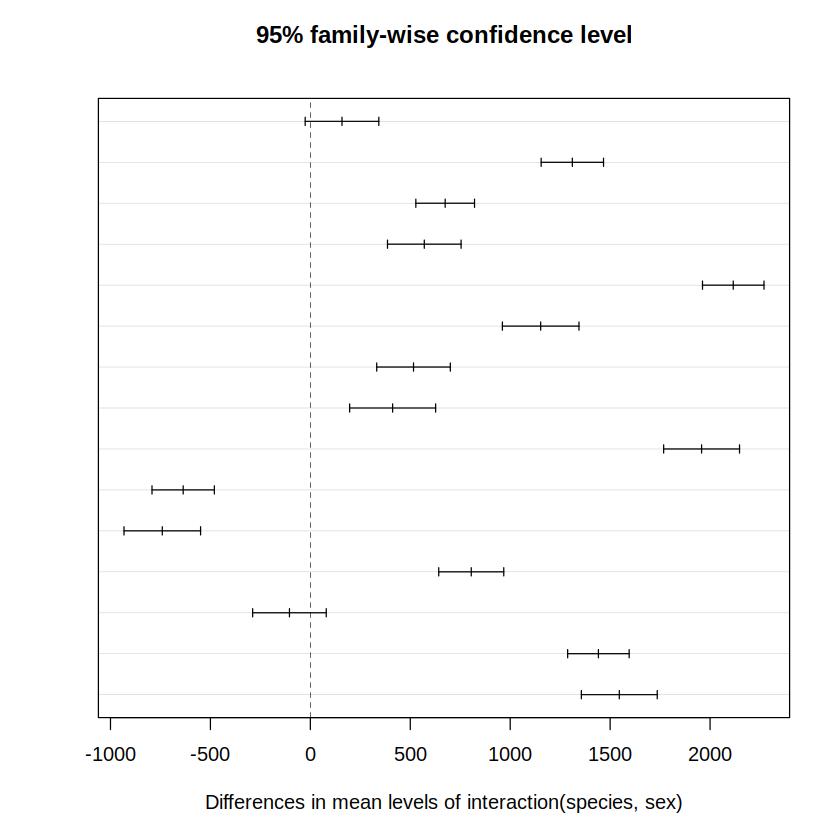

In [78]:
plot(TukeyHSD(anova_body), yaxt = 'n')

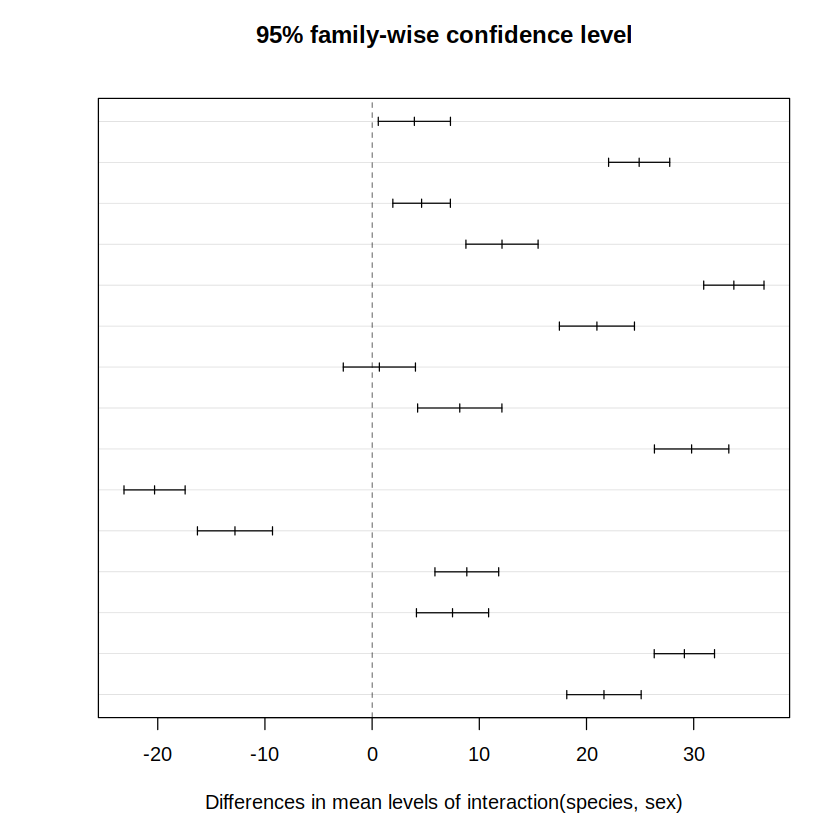

In [79]:
plot(TukeyHSD(anova_flipper), yaxt = 'n')

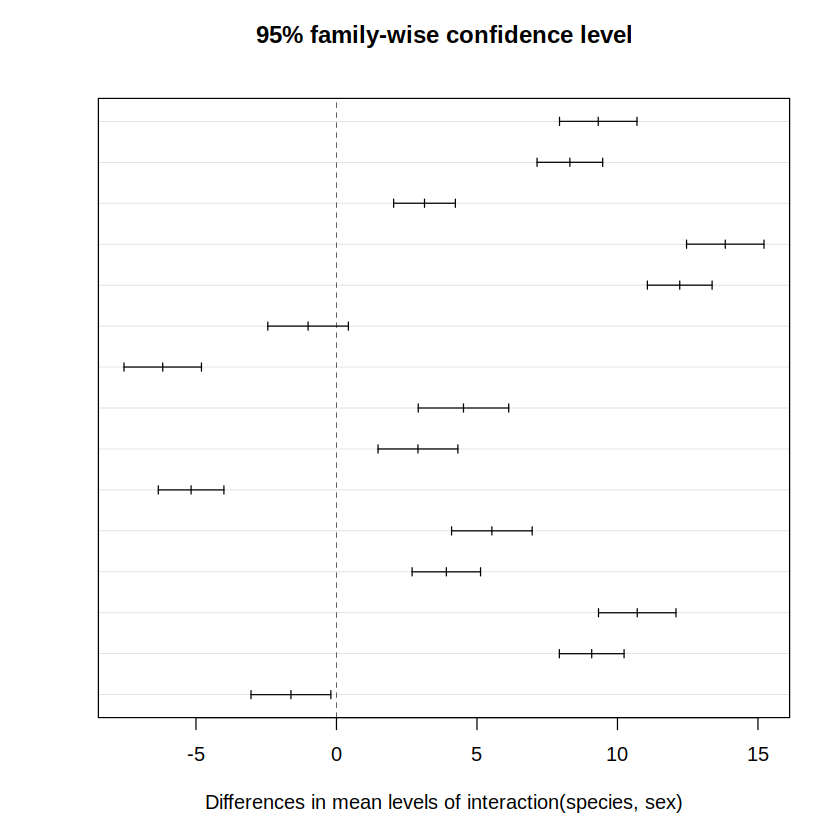

In [80]:
plot(TukeyHSD(anova_bill_l), yaxt = 'n')

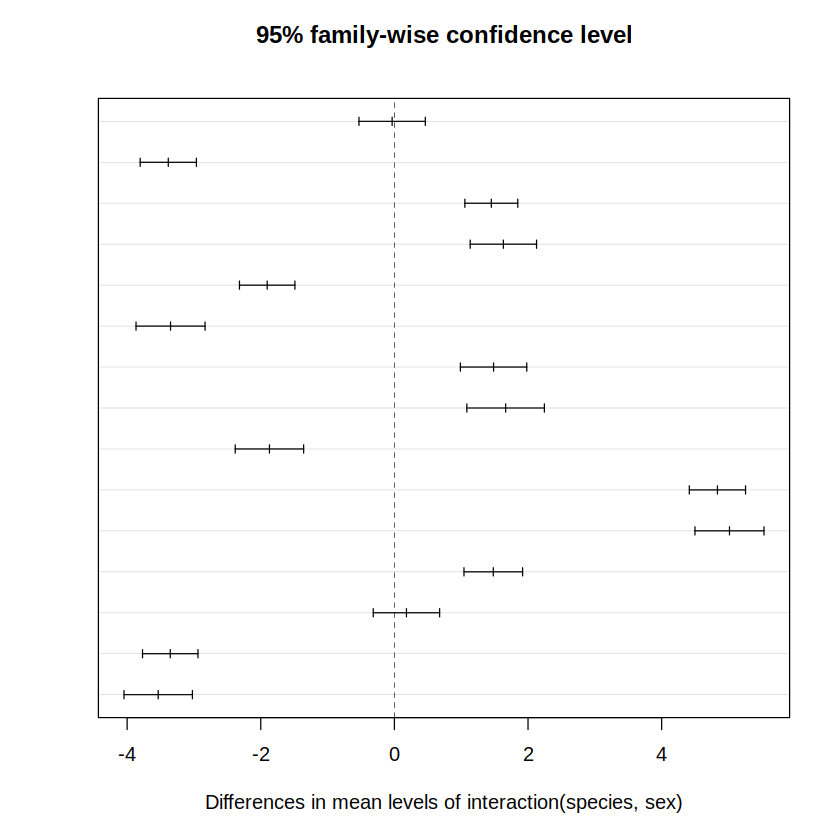

In [81]:
plot(TukeyHSD(anova_bill_d), yaxt = 'n')


In [42]:
save.image()